In [10]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise;

  Activating project at `~/Github_Projects/JJDFTX.jl`


In [11]:
using PyPlot, PyCall, Statistics, JJDFTX, LinearAlgebra;#, StatsBase;
interpolate = pyimport("scipy.interpolate").interp1d;

In [12]:
li_dir="./Lithium";
na_dir="./Sodium";
k_dir="./Potassium";
rb_dir="./Rubidium";
cs_dir="./Cesium";

### Below, we obtain the equilibrium distances (corresponding to minimum energy configurations)

In [13]:
Na_Energies, Na_dists, Li_Energies, Li_dists, K_Energies,
K_dists, Rb_Energies, Rb_dists, Cs_Energies, Cs_dists = [zeros(100) for i in 1:10]
for i in 1:100
    Na_Energies[i] = list_energy("$na_dir/output/Sodium-$i.out")
    Na_dists[i] = get_d("$na_dir/output/Sodium-$i.out", "Na")

    Li_Energies[i] = list_energy("$li_dir/output/Lithium-$i.out")
    Li_dists[i] = get_d("$li_dir/output/Lithium-$i.out", "Li")

    K_Energies[i] = list_energy("$k_dir/output/Potassium-$i.out")
    K_dists[i] = get_d("$k_dir/output/Potassium-$i.out", "K")

    Rb_Energies[i] = list_energy("$rb_dir/output/Rubidium-$i.out")
    Rb_dists[i] = get_d("$rb_dir/output/Rubidium-$i.out", "Rb")

    Cs_Energies[i] = list_energy("$cs_dir/output/Cesium-$i.out")
    Cs_dists[i] = get_d("$cs_dir/output/Cesium-$i.out", "Cs")
end

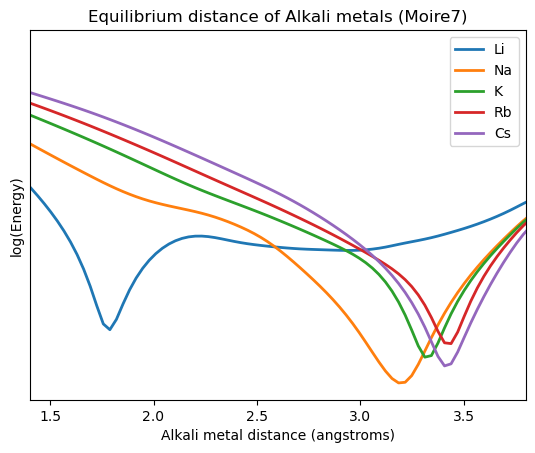

In [14]:
linewidth = 2
plot(Li_dists, log.(smooth(Li_Energies, win_len=10) .- minimum(Li_Energies) .+ 0.001), linewidth=linewidth, label="Li")
plot(Na_dists[1:90], log.(smooth(Na_Energies[1:90], win_len=10) .- minimum(Na_Energies) .+ 0.001), linewidth=linewidth, label="Na")
plot(K_dists, log.(smooth(K_Energies, win_len=10) .- minimum(K_Energies) .+ 0.0001), linewidth=linewidth, label="K")
plot(Rb_dists, log.(smooth(Rb_Energies, win_len=10) .- minimum(Rb_Energies) .+ 0.001), linewidth=linewidth, label="Rb")
plot(Cs_dists, log.(smooth(Cs_Energies, win_len=10) .- minimum(Cs_Energies) .+ 0.001), linewidth=linewidth, label="Cs")
xlabel("Alkali metal distance (angstroms)")
title("Equilibrium distance of Alkali metals (Moire7)")
yticks([])
ylabel("log(Energy)")
legend();
xlim(1.4, 3.8);

In [15]:
println("Equilibrium distance for Li: ", round(Li_dists[argmin(Li_Energies)], digits=4), " angstroms")
println("Equilibrium distance for Na: ", round(Na_dists[argmin(Na_Energies)], digits=4), " angstroms")
println("Equilibrium distance for K: ", round(K_dists[argmin(K_Energies)], digits=4), " angstroms")
println("Equilibrium distance for Rb: ", round(Rb_dists[argmin(Rb_Energies)], digits=4), " angstroms")
println("Equilibrium distance for Cs: ", round(Cs_dists[argmin(Cs_Energies)], digits=4), " angstroms")

Equilibrium distance for Li: 1.7886 angstroms
Equilibrium distance for Na: 3.2491 angstroms
Equilibrium distance for K: 3.3126 angstroms
Equilibrium distance for Rb: 3.4397 angstroms
Equilibrium distance for Cs: 3.4397 angstroms


In [16]:
# Number of electrons, bands: 
# Lithium: 115, 114
# Sodium: 121, 117
# Potassium: 121, 117
# Rubidium: 121, 117
# Cesium: 121, 117

In [17]:
EsUp, dosUp = JJDFTX.load_dos_data("$li_dir/dos/Li-0.169.dosUp");
EsDn, dosDn= JJDFTX.load_dos_data("$li_dir/dos/Li-0.169.dosDn");
esUp, csUp = find_chemical_potential(EsUp, dosUp);
esDn, csDn = find_chemical_potential(EsDn, dosDn);

In [18]:
f_up = interpolate(esUp, csUp)
f_dn = interpolate(esDn, csDn)
energy_range = -6:0.1:0
μ_li = energy_range[argmin(abs.(first.(f_up.(energy_range)+f_dn.(energy_range)) .- 115))];

In [21]:
EsUp, dosUp = JJDFTX.load_dos_data("$na_dir/dos/Na-0.307.dosUp");
EsDn, dosDn= JJDFTX.load_dos_data("$na_dir/dos/Na-0.307.dosDn");
esUp, csUp = find_chemical_potential(EsUp, dosUp);
esDn, csDn = find_chemical_potential(EsDn, dosDn);

In [22]:
f_up = interpolate(esUp, csUp)
f_dn = interpolate(esDn, csDn)
energy_range = -6:0.1:0
μ_na = energy_range[argmin(abs.(first.(f_up.(energy_range)+f_dn.(energy_range)) .- 121))];

In [23]:
EsUp, dosUp = JJDFTX.load_dos_data("$k_dir/dos/K-0.313.dosUp");
EsDn, dosDn= JJDFTX.load_dos_data("$k_dir/dos/K-0.313.dosDn");
esUp, csUp = find_chemical_potential(EsUp, dosUp);
esDn, csDn = find_chemical_potential(EsDn, dosDn);

In [24]:
f_up = interpolate(esUp, csUp)
f_dn = interpolate(esDn, csDn)
energy_range = -6:0.1:0
μ_k = energy_range[argmin(abs.(first.(f_up.(energy_range)+f_dn.(energy_range)) .- 121))];

In [25]:
EsUp, dosUp = JJDFTX.load_dos_data("$rb_dir/dos/Rb-0.325.dosUp");
EsDn, dosDn= JJDFTX.load_dos_data("$rb_dir/dos/Rb-0.325.dosDn");
esUp, csUp = find_chemical_potential(EsUp, dosUp);
esDn, csDn = find_chemical_potential(EsDn, dosDn);

In [26]:
f_up = interpolate(esUp, csUp)
f_dn = interpolate(esDn, csDn)
energy_range = -6:0.1:0
μ_rb = energy_range[argmin(abs.(first.(f_up.(energy_range)+f_dn.(energy_range)) .- 121))];

In [27]:
EsUp, dosUp = JJDFTX.load_dos_data("$cs_dir/dos/Cs-0.325.dosUp");
EsDn, dosDn= JJDFTX.load_dos_data("$cs_dir/dos/Cs-0.325.dosDn");
esUp, csUp = find_chemical_potential(EsUp, dosUp);
esDn, csDn = find_chemical_potential(EsDn, dosDn);

In [28]:
f_up = interpolate(esUp, csUp)
f_dn = interpolate(esDn, csDn)
energy_range = -6:0.1:0
μ_cs = energy_range[argmin(abs.(first.(f_up.(energy_range)+f_dn.(energy_range)) .- 121))];

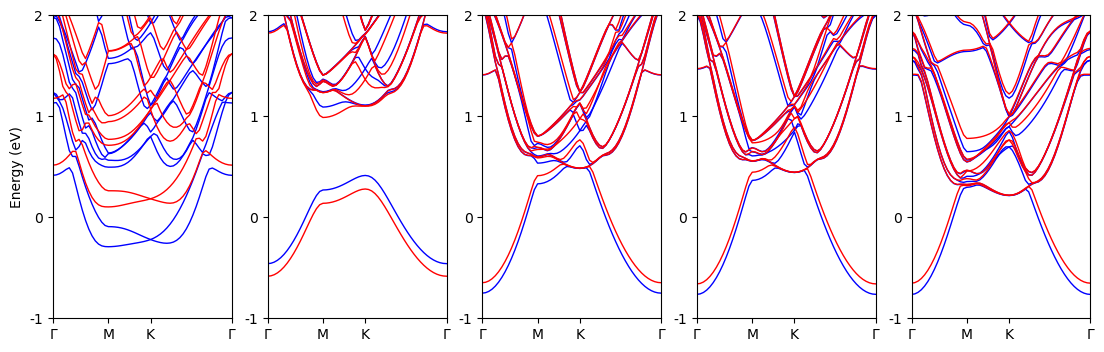

In [29]:
cm = 1/2.54
figure(figsize=(34*cm, 10*cm))
#figure(figsize=(17*cm, 5*cm))
num_cols = 5
num_rows = 1
subplot(num_rows, num_cols, 1)
plot_bands("$li_dir/eigenvals/Li-bands-0.169.eigenvals", spin=2, to_greek=true, linewidth=1)
xlabel("")
ylim(μ_li-1, μ_li+2)
yticks([μ_li-1, μ_li, μ_li+1, μ_li+2], [-1, 0, 1, 2])

subplot(num_rows, num_cols, 2)
plot_bands("$na_dir/eigenvals/Na-bands-0.307.eigenvals", spin=2, to_greek=true, linewidth=1)
xlabel("")
yticks([])
ylabel("")
ylim(μ_na-1, μ_na+2)
yticks([μ_na-1, μ_na, μ_na+1, μ_na+2], [-1, 0, 1, 2])

subplot(num_rows, num_cols, 3)
plot_bands("$k_dir/eigenvals/K-bands-0.313.eigenvals", spin=2, to_greek=true, linewidth=1)
xlabel("")
ylabel("")
ylim(μ_k-1, μ_k+2)
yticks([μ_k-1, μ_k, μ_k+1, μ_k+2], [-1, 0, 1, 2])

subplot(num_rows, num_cols, 4)
plot_bands("$rb_dir/eigenvals/Rb-bands-0.325.eigenvals", spin=2, to_greek=true, linewidth=1)
xlabel("")
yticks([])
ylabel("")
ylim(μ_rb-1, μ_rb+2)
yticks([μ_rb-1, μ_rb, μ_rb+1, μ_rb+2], [-1, 0, 1, 2])

subplot(num_rows, num_cols, 5)
plot_bands("$cs_dir/eigenvals/Cs-bands-0.325.eigenvals", spin=2, to_greek=true, linewidth=1)
xlabel("")
ylabel("")
ylim(μ_cs-1, μ_cs+2)
yticks([μ_cs-1, μ_cs, μ_cs+1, μ_cs+2], [-1, 0, 1, 2]);
#savefig("Moire7bands.pdf")

Total number of electrons in range: 32.72854616573719


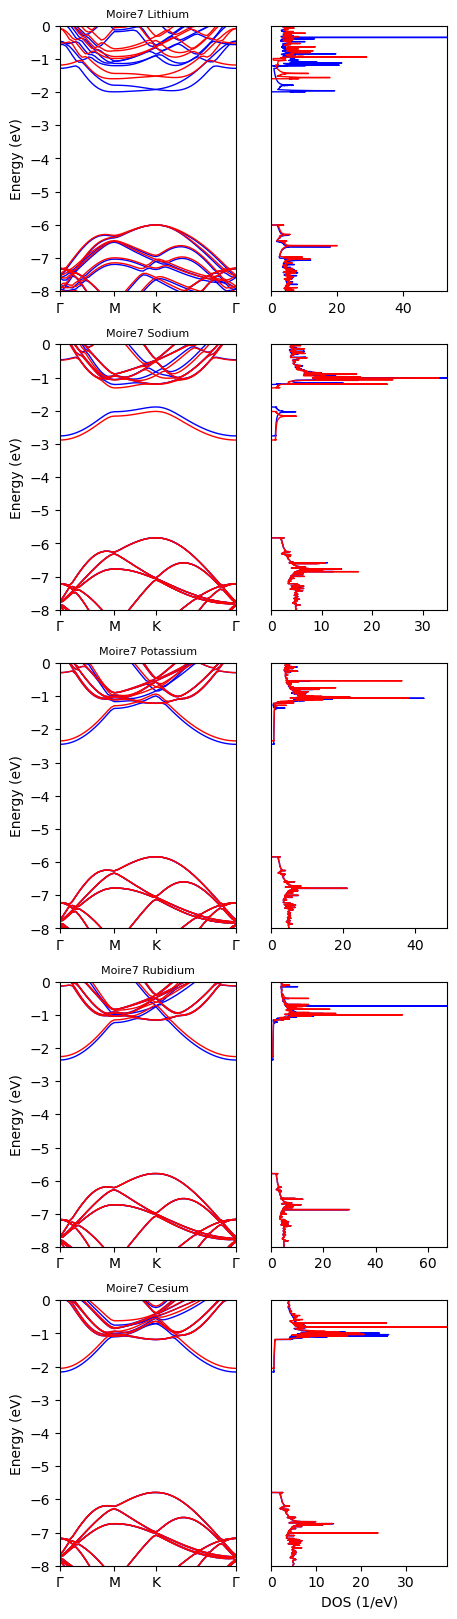

In [30]:
figure(figsize=(5, 20))
bands_overlayed_dos("$li_dir/dos/Li-0.169.dosUp", "$li_dir/dos/Li-0.169.dosDn", "$li_dir/eigenvals/Li-bands-0.169.eigenvals"
, energy_range=(-8, 0), band_subplot=[5, 2, 1], dos_subplot=[5, 2, 2], linewidth=1,dos_yticks=false)
bands_overlayed_dos("$na_dir/dos/Na-0.307.dosUp", "$na_dir/dos/Na-0.307.dosDn", "$na_dir/eigenvals/Na-bands-0.307.eigenvals"
, energy_range=(-8, 0), band_subplot=[5, 2, 3], dos_subplot=[5, 2, 4], linewidth=1, dos_yticks=false)
bands_overlayed_dos("$k_dir/dos/K-0.313.dosUp", "$k_dir/dos/K-0.313.dosDn", "$k_dir/eigenvals/K-bands-0.313.eigenvals"
, energy_range=(-8, 0), band_subplot=[5, 2, 5], dos_subplot=[5, 2, 6], linewidth=1, dos_yticks=false)
bands_overlayed_dos("$rb_dir/dos/Rb-0.325.dosUp", "$rb_dir/dos/Rb-0.325.dosDn", "$rb_dir/eigenvals/Rb-bands-0.325.eigenvals"
, energy_range=(-8, 0), band_subplot=[5, 2, 7], dos_subplot=[5, 2, 8], linewidth=1, dos_yticks=false)
bands_overlayed_dos("$cs_dir/dos/Cs-0.325.dosUp", "$cs_dir/dos/Cs-0.325.dosDn", "$cs_dir/eigenvals/Cs-bands-0.325.eigenvals"
, energy_range=(-8, 0), band_subplot=[5, 2, 9], dos_subplot=[5, 2, 10], dos_yticks=false, linewidth=1,return_tot=true)

subplot(5, 2, 2)
xlabel("")
subplot(5, 2, 4)
xlabel("")
subplot(5, 2, 6)
xlabel("")
subplot(5, 2, 8)
xlabel("")
subplot(5, 2, 1)
title("Moire7 Lithium", fontsize=8)
subplot(5, 2, 3)
title("Moire7 Sodium", fontsize=8)
subplot(5, 2, 5)
title("Moire7 Potassium", fontsize=8)
subplot(5, 2, 7)
title("Moire7 Rubidium", fontsize=8)
subplot(5, 2, 9)
title("Moire7 Cesium", fontsize=8);